# Breast cancer Recognintion using Machine Learning
### Dataset: winconsin "Breast_cancer_dataset.csv"
### Algorithm: LOGISTIC REGRESSION

In [1]:
# Import the required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# import the dataset
cancer_df = pd.read_csv("Breast_cancer_dataset.csv")
cancer_df.head(10)

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN
5,843786,M,12.45,15.70,82.57,477.1,0.12780,0.17000,0.15780,0.08089,...,23.75,103.40,741.6,0.1791,0.5249,0.5355,0.1741,0.3985,0.12440,NaN
6,844359,M,18.25,19.98,119.60,1040.0,0.09463,0.10900,0.11270,0.07400,...,27.66,153.20,1606.0,0.1442,0.2576,0.3784,0.1932,0.3063,0.08368,NaN
7,84458202,M,13.71,20.83,90.20,577.9,0.11890,0.16450,0.09366,0.05985,...,28.14,110.60,897.0,0.1654,0.3682,0.2678,0.1556,0.3196,0.11510,NaN
8,844981,M,13.00,21.82,87.50,519.8,0.12730,0.19320,0.18590,0.09353,...,30.73,106.20,739.3,0.1703,0.5401,0.5390,0.2060,0.4378,0.10720,NaN
9,84501001,M,12.46,24.04,83.97,475.9,0.11860,0.23960,0.22730,0.08543,...,40.68,97.65,711.4,0.1853,1.0580,1.1050,0.2210,0.4366,0.20750,NaN


In [3]:
cancer_df.head(10).T

,0,1,2,3,4,5,6,7,8,9
id,842302,842517,84300903,84348301,84358402,843786,844359,84458202,844981,84501001
diagnosis,M,M,M,M,M,M,M,M,M,M
radius_mean,17.99,20.57,19.69,11.42,20.29,12.45,18.25,13.71,13.0,12.46
texture_mean,10.38,17.77,21.25,20.38,14.34,15.7,19.98,20.83,21.82,24.04
perimeter_mean,122.8,132.9,130.0,77.58,135.1,82.57,119.6,90.2,87.5,83.97
area_mean,1001.0,1326.0,1203.0,386.1,1297.0,477.1,1040.0,577.9,519.8,475.9
smoothness_mean,0.1184,0.08474,0.1096,0.1425,0.1003,0.1278,0.09463,0.1189,0.1273,0.1186
compactness_mean,0.2776,0.07864,0.1599,0.2839,0.1328,0.17,0.109,0.1645,0.1932,0.2396
concavity_mean,0.3001,0.0869,0.1974,0.2414,0.198,0.1578,0.1127,0.09366,0.1859,0.2273
concave points_mean,0.1471,0.07017,0.1279,0.1052,0.1043,0.08089,0.074,0.05985,0.09353,0.08543


In [4]:
cancer_df.shape

(569, 33)

In [5]:
cancer_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [6]:
cancer_df.describe()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,0.0
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,NaN
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,NaN
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,NaN
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,NaN
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,NaN
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,NaN
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,NaN


In [7]:
cancer_df.duplicated().sum()

np.int64(0)

- From here we can conclude that there is no duplicate values in the dataset

In [8]:
cancer_df.isnull().sum()

id                           0
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave points_worst         0
symmetry_worst               0
fractal_dimension_worst      0
Unnamed:

- There is no null values present in this dataset except that of the `Unnamed: 32` column, so we drop it.

In [9]:
cancer_df.drop("Unnamed: 32", axis=1, inplace=True)

In [10]:
cancer_df.drop("id", axis=1, inplace=True)

In [11]:
cancer_df.shape

(569, 31)

In [12]:
cancer_df.columns

Index(['diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst'],
      dtype='object')

- In this dataset, there are now 32 columns, and 569 rows, of which there is a categorical column named "diagnosis" which is the target variable(output label) and all rest columns are Numerical type which are the features.

**Let us explore the output/target variable**

In [13]:
cancer_df["diagnosis"].value_counts()

diagnosis
B    357
M    212
Name: count, dtype: int64

##### Here `M` is for malignant class (cancerous patient) & `B` is for Benign class (non-cancerous patients). So, there are 357 data points belongs to the Benign class while there are 212 data points belongs to the Malignant class which leads to a class imbalance in the dataset.

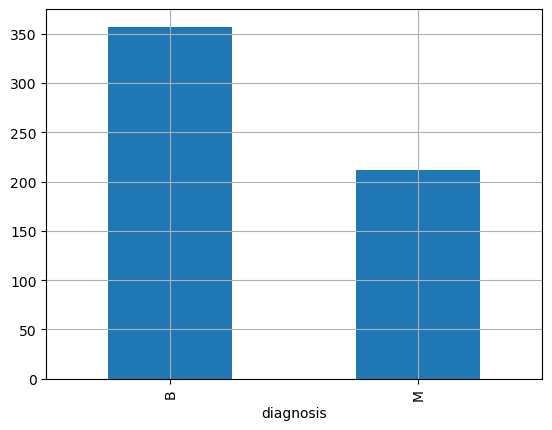

In [14]:
cancer_df["diagnosis"].value_counts().plot.bar()
plt.grid()

<Axes: ylabel='count'>

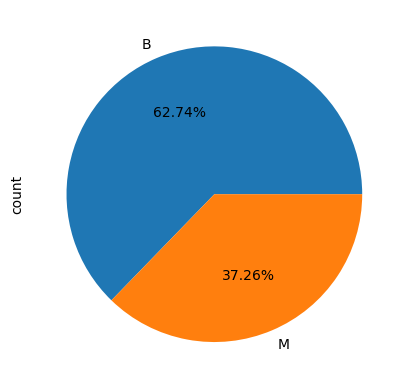

In [15]:
cancer_df["diagnosis"].value_counts().plot.pie(autopct = '%0.2f%%')

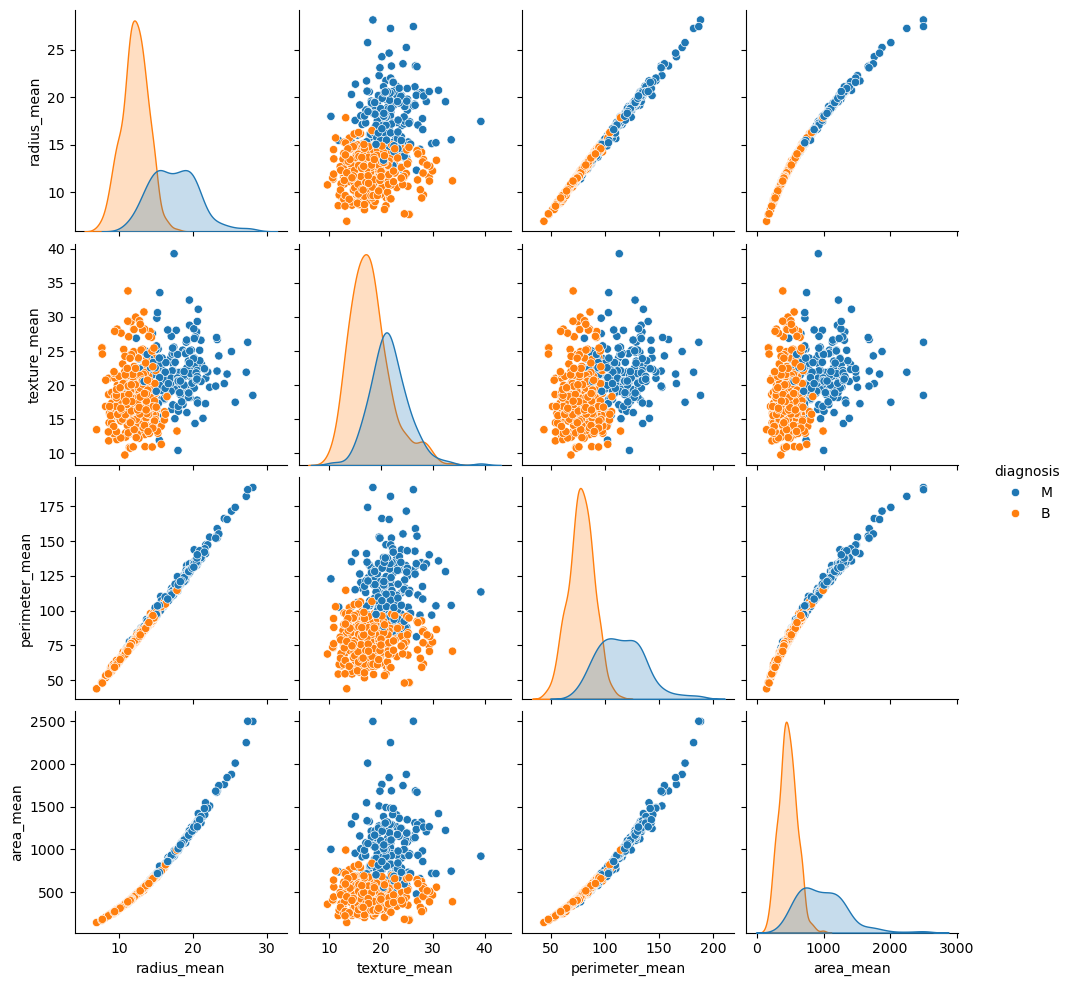

In [16]:
sns.pairplot(cancer_df[['radius_mean',
                        'texture_mean',
                        'perimeter_mean',
                        'area_mean',
                        'diagnosis']],
             hue='diagnosis')
plt.show()

- #### Inference:
Malignant tumors appear to have larger radius and perimeter values.

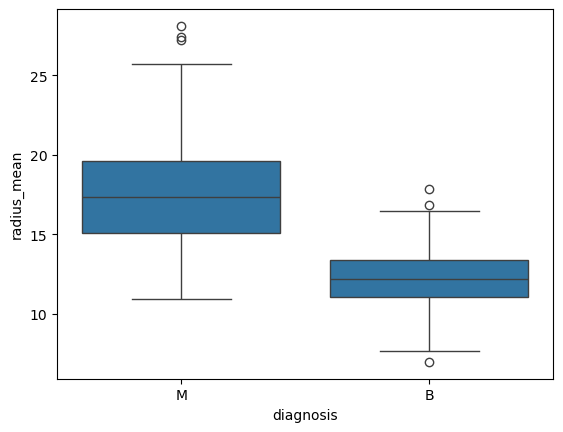

In [17]:
sns.boxplot(x='diagnosis', y='radius_mean', data=cancer_df)
plt.show()

**The outliers shown in the above boxplot may be important as there are some data in medical field which may be important, so we should avoid dropping these outliers**

### Split the data into X and y

In [18]:
X = cancer_df.drop("diagnosis", axis = 1)
y = cancer_df["diagnosis"]

In [19]:
y.unique()

array(['M', 'B'], dtype=object)

In [20]:
cancer_df.shape

(569, 31)

In [21]:
X.shape[0]

569

In [22]:
y.shape[0]

569

In [23]:
X.corr()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
radius_mean,1.000000,0.323782,0.997855,0.987357,0.170581,0.506124,0.676764,0.822529,0.147741,-0.311631,...,0.969539,0.297008,0.965137,0.941082,0.119616,0.413463,0.526911,0.744214,0.163953,0.007066
texture_mean,0.323782,1.000000,0.329533,0.321086,-0.023389,0.236702,0.302418,0.293464,0.071401,-0.076437,...,0.352573,0.912045,0.358040,0.343546,0.077503,0.277830,0.301025,0.295316,0.105008,0.119205
perimeter_mean,0.997855,0.329533,1.000000,0.986507,0.207278,0.556936,0.716136,0.850977,0.183027,-0.261477,...,0.969476,0.303038,0.970387,0.941550,0.150549,0.455774,0.563879,0.771241,0.189115,0.051019
area_mean,0.987357,0.321086,0.986507,1.000000,0.177028,0.498502,0.685983,0.823269,0.151293,-0.283110,...,0.962746,0.287489,0.959120,0.959213,0.123523,0.390410,0.512606,0.722017,0.143570,0.003738
smoothness_mean,0.170581,-0.023389,0.207278,0.177028,1.000000,0.659123,0.521984,0.553695,0.557775,0.584792,...,0.213120,0.036072,0.238853,0.206718,0.805324,0.472468,0.434926,0.503053,0.394309,0.499316
compactness_mean,0.506124,0.236702,0.556936,0.498502,0.659123,1.000000,0.883121,0.831135,0.602641,0.565369,...,0.535315,0.248133,0.590210,0.509604,0.565541,0.865809,0.816275,0.815573,0.510223,0.687382
concavity_mean,0.676764,0.302418,0.716136,0.685983,0.521984,0.883121,1.000000,0.921391,0.500667,0.336783,...,0.688236,0.299879,0.729565,0.675987,0.448822,0.754968,0.884103,0.861323,0.409464,0.514930
concave points_mean,0.822529,0.293464,0.850977,0.823269,0.553695,0.831135,0.921391,1.000000,0.462497,0.166917,...,0.830318,0.292752,0.855923,0.809630,0.452753,0.667454,0.752399,0.910155,0.375744,0.368661
symmetry_mean,0.147741,0.071401,0.183027,0.151293,0.557775,0.602641,0.500667,0.462497,1.000000,0.479921,...,0.185728,0.090651,0.219169,0.177193,0.426675,0.473200,0.433721,0.430297,0.699826,0.438413
fractal_dimension_mean,-0.311631,-0.076437,-0.261477,-0.283110,0.584792,0.565369,0.336783,0.166917,0.479921,1.000000,...,-0.253691,-0.051269,-0.205151,-0.231854,0.504942,0.458798,0.346234,0.175325,0.334019,0.767297


- Clearly we can see that the features like perimeter_mean, area_mean, radius_worst, perimeter_worst, area_worst are strongly correlated with each other, indicating possible multicollinearity.

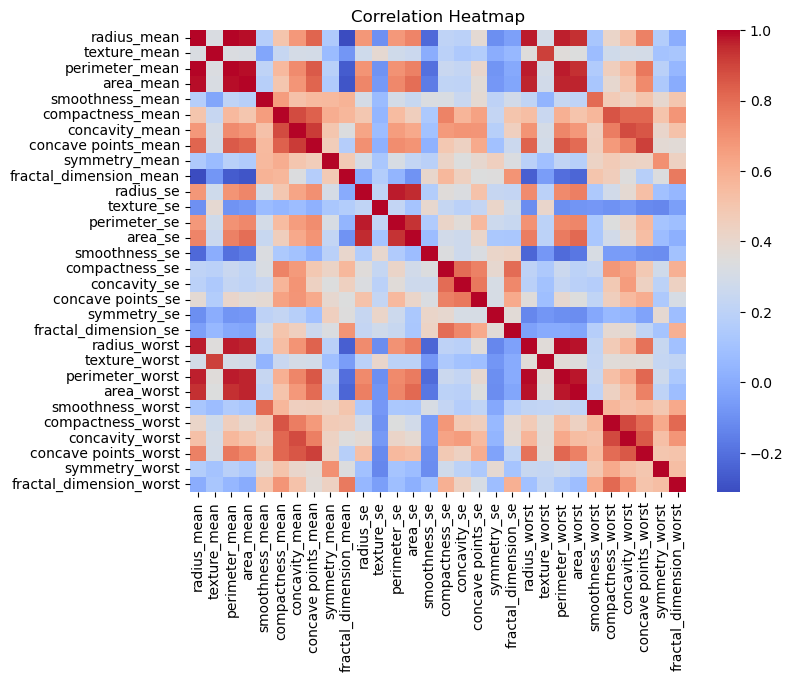

In [24]:
plt.figure(figsize=(8,6))
sns.heatmap(X.corr(), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [25]:
from sklearn.preprocessing import LabelEncoder
label_enc = LabelEncoder()

In [26]:
y_encoded = label_enc.fit_transform(y)

In [27]:
y_encoded

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1,
       0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1,
       0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1,
       1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0,
       0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1,
       1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1,

In [28]:
from sklearn.model_selection import train_test_split

In [29]:
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size = 0.2, random_state = 42)

- We used 80% data points for training and 20% data points for testing

In [30]:
print("Number of the training features data points is:", X_train.shape[0])
print("Number of the testing features data points is:", X_test.shape[0])
print("Number of the training output data points is:", y_train.shape[0])
print("Number of the testing output data points is:", y_test.shape[0])

Number of the training features data points is: 455
Number of the testing features data points is: 114
Number of the training output data points is: 455
Number of the testing output data points is: 114


### Building a Logistic Regression Model

In [31]:
from sklearn.linear_model import LogisticRegression

In [50]:
logReg_model = LogisticRegression(max_iter = 200) # It should not give any warning for maximum iterations at 200

In [51]:
logReg_model.fit(X_train, y_train)

C:\Users\mdmoz\Anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 200 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=200).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,200
,multi_class,'deprecated'


In [34]:
y_train_predicted = logReg_model.predict(X_train)
y_test_predicted = logReg_model.predict(X_test)

In [35]:
y_train_predicted.shape[0]

455

In [36]:
y_test_predicted.shape[0]

114

#### Let's evaluate our Logistic Regression model with the help of evaluation metrics

In [37]:
from sklearn.metrics import accuracy_score

In [38]:
print("The accuracy score of the model on the train dataset")
print("-------------------------------------------------------------")
print(accuracy_score(y_train, y_train_predicted))

The accuracy score of the model on the train dataset
-------------------------------------------------------------
0.9604395604395605


In [39]:
print("The accuracy score of the model on the test dataset")
print("-------------------------------------------------------------")
print(accuracy_score(y_test, y_test_predicted))

The accuracy score of the model on the test dataset
-------------------------------------------------------------
0.956140350877193


- ##### From above we can infer that this logReg model is an appropriate fit model for the given dataset.
##### Inference:
- The model achieved high accuracy, indicating strong classification capability.

In [40]:
from sklearn.metrics import classification_report

In [41]:
print("The classification evaluation report/metrics on the logReg model on the test dataset is:")
print(classification_report(y_test, y_test_predicted))

The classification evaluation report/metrics on the logReg model on the test dataset is:
              precision    recall  f1-score   support

           0       0.95      0.99      0.97        71
           1       0.97      0.91      0.94        43

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



In [42]:
print("The classification evaluation report/metrics on the logReg model on the train dataset is:")
print(classification_report(y_train, y_train_predicted))

The classification evaluation report/metrics on the logReg model on the train dataset is:
              precision    recall  f1-score   support

           0       0.96      0.98      0.97       286
           1       0.96      0.93      0.95       169

    accuracy                           0.96       455
   macro avg       0.96      0.96      0.96       455
weighted avg       0.96      0.96      0.96       455



In [43]:
# direct method to show the confusion matrix 
from sklearn.metrics import confusion_matrix

print("The confusion matrix for the test dataset:")
print(confusion_matrix(y_test, y_test_predicted))

The confusion matrix for the test dataset:
[[70  1]
 [ 4 39]]


- Thus in binary classification of confusion matrix, the count of
  - True Negative (TN) is at (0,0) index --- 70
  - False Negative (FN) is at (1,0) index --- 4
  - False positive (FP) is at (0,1) index --- 1
  - True Positive (TP) is at (1,1) index --- 39

**Inference: The model produced very few false negatives, which is critical in cancer detection.**

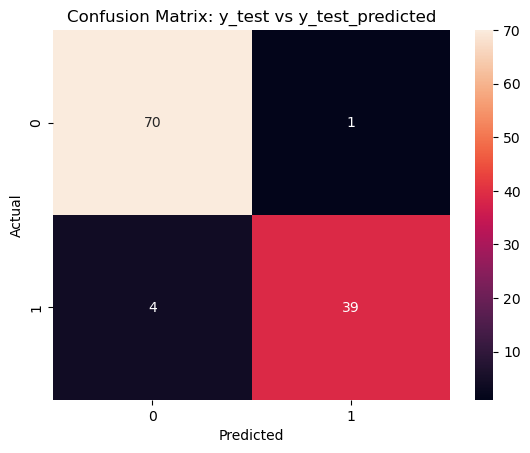

In [44]:
cm = confusion_matrix(y_test, y_test_predicted)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix: y_test vs y_test_predicted")
plt.show()

In [45]:
# for understanding the confusion matrix, let us define it as an actual matrix acc. to the confusion parameters
CM = pd.DataFrame([['TN', 'FP'],
                   ['FN', 'TP']])
CM

,0,1
0,TN,FP
1,FN,TP


In [46]:
# Confusion matrix of the test data
a = pd.DataFrame([[70, 1],
                 [ 4, 39]])
a

,0,1
0,70,1
1,4,39


In [47]:
print("The confusion matrix for the train dataset:")
print(confusion_matrix(y_train, y_train_predicted))

The confusion matrix for the train dataset:
[[279   7]
 [ 11 158]]


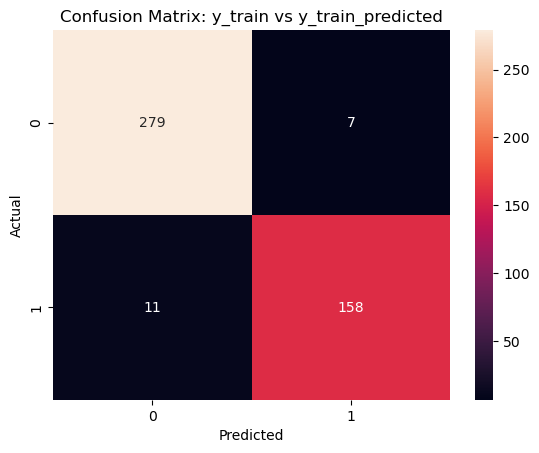

In [48]:
cm = confusion_matrix(y_train, y_train_predicted)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix: y_train vs y_train_predicted")
plt.show()

In [49]:
# Confusion matrix of the train data
b = pd.DataFrame([[274,12],
                 [24,145]])
b

,0,1
0,274,12
1,24,145


***It is an appropriate fit model with an accuracy score of 92% on the train dataset & 95% on the test dataset, Precision of 92% on both Bening and malignant class, recall of 96% on Benign class and 86% on malignant class & f1_score of  94% on Bening and 89% on malignant class***

---
### __Observation:__

- **Training Accuracy (92.04%):**

  Indicates that the logistic regression model correctly classifies 92.04% of the training instances.
  A high training accuracy suggests that the model has learned the patterns present in the training data well.

- **Testing Accuracy (95.61%):**

  This indicates that the model correctly classifies 95.61% of the instances in the test set, which was not seen during training.
  High testing accuracy suggests that the model generalizes well to new, unseen data.

- **Model Performance:**

  Both training and testing accuracies are high, indicating good overall performance of the logistic regression model.
  The slight increase from training to testing accuracy (from 92.04% to 95.61%) is expected and acceptable, showing that the model generalizes well without overfitting.

- **Check for Overfitting:**

  If the training accuracy were significantly higher than the testing accuracy, it would suggest overfitting. However, in this case, the difference is small, indicating that the model is not overfitting.

  ---

## Now let us build an KNN model for this dataset

In [52]:
from sklearn.neighbors import KNeighborsClassifier

In [57]:
knn_model = KNeighborsClassifier(n_neighbors = 3)

In [58]:
knn_model.fit(X_train, y_train)

,n_neighbors,3
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [59]:
y_test_pred_knn = knn_model.predict(X_test)
y_train_pred_knn = knn_model.predict(X_train)

### Evaluating the KNN model

In [60]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

In [61]:
print("The accuracy score tof the KNN model on the test dataset is: ", accuracy_score(y_test,y_test_pred_knn ))

The accuracy score tof the KNN model on the test dataset is:  0.9298245614035088


In [62]:
print("The accuracy score tof the KNN model on the train dataset is: ", accuracy_score(y_train,y_train_pred_knn ))

The accuracy score tof the KNN model on the train dataset is:  0.9494505494505494


In [67]:
print("Classification report of KNN model on the  test dataset\n\n", classification_report(y_test,y_test_pred_knn ))

Classification report of KNN model on the  test dataset

               precision    recall  f1-score   support

           0       0.93      0.96      0.94        71
           1       0.93      0.88      0.90        43

    accuracy                           0.93       114
   macro avg       0.93      0.92      0.92       114
weighted avg       0.93      0.93      0.93       114



In [66]:
print("Classification report of KNN model on the  train dataset\n\n", classification_report(y_train,y_train_pred_knn ))

Classification report of KNN model on the  train dataset

               precision    recall  f1-score   support

           0       0.94      0.98      0.96       286
           1       0.97      0.89      0.93       169

    accuracy                           0.95       455
   macro avg       0.95      0.94      0.94       455
weighted avg       0.95      0.95      0.95       455



- ***The KNN model is also an appropriate fit model on the given dataset with an acuuracy score of 93% on the test dataset and 95% on the train dataset.***

---

## Now Let us build an SVM model on this dataset

In [68]:
from sklearn.svm import SVC

In [69]:
svm_model = SVC()

In [70]:
svm_model.fit(X_train, y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [71]:
y_test_predicted_svm = svm_model.predict(X_test)
y_train_predicted_svm = svm_model.predict(X_train)

#### Evaluating the SVM Model

In [72]:
print("The accuracy score of the SVM model on the test dataset is ", accuracy_score(y_test, y_test_predicted_svm))

The accuracy score of the SVM model on the test dataset is  0.9473684210526315


In [73]:
print("The accuracy score of the SVM model on the train dataset is ", accuracy_score(y_train, y_train_predicted_svm))

The accuracy score of the SVM model on the train dataset is  0.9142857142857143


In [74]:
print("Classification report of KNN model on the  test dataset\n\n", classification_report(y_test, y_test_predicted_svm))

Classification report of KNN model on the  test dataset

               precision    recall  f1-score   support

           0       0.92      1.00      0.96        71
           1       1.00      0.86      0.93        43

    accuracy                           0.95       114
   macro avg       0.96      0.93      0.94       114
weighted avg       0.95      0.95      0.95       114



In [76]:
print("Classification report of KNN model on the  train dataset\n\n", classification_report(y_train, y_train_predicted_svm))

Classification report of KNN model on the  train dataset

               precision    recall  f1-score   support

           0       0.89      0.98      0.94       286
           1       0.96      0.80      0.87       169

    accuracy                           0.91       455
   macro avg       0.93      0.89      0.90       455
weighted avg       0.92      0.91      0.91       455



- ***We can infer from the above results that the SVM model is an appropriate fit model with a model training accuracy of 91% and model testing accuracy of 95%***

---
- **Comparison of accuracies of each models:**
   - *Logistic Regression Algorithm:* 
        - Training accuracy = 96.04%
        - Testing accuracy = 95.61%
   - *K-Nearest Neighbors Algorithm:*
        - Training accuracy = 94.94%
        - Testing accuracy = 92.98% 
   - *Support Vector Machine Algorithm:*
        - Training accuracy = 91.42%
        - Testing accuracy = 94.73%

---
**CONCLUSION:**
- Among the three machine learning models we have used for prediction, the Logistic regression model is the best fitting model among all having an accuracy of 96% on training data and 95% on test data.
- The logistic regression model also has a high precision, f1 score and recall value, all of them are above 95% .